# Plot impact of population size

Consider the time of the MRCA of 2 individuals with a sequence length $L$, $k$ mutations and a mutation rate $\mu$ assuming the infinite site model.
The population size is modeled as a function of time $N(t)$. This gives the following posterior distribution of $t_{MRCA}$:
$$
P(t_{MRCA}|k) = \frac{P(k|t_{MRCA})\cdot P(t_{MRCA}|N)}{P(k)} \propto P(k|t_{MRCA})\cdot P(t_{MRCA}|N)
$$

with: 
$$
P(k|t_{MRCA}) = \frac{(2 \cdot \mu \cdot L \cdot t_{MRCA})^k}{k!} \, e^{-2 \mu L s}
$$ 
and:
$$
P(t_{MRCA}|N) = \frac{1}{N(t_{\text{present}} - t_{MRCA}) \cdot g} \cdot e^{- \int_0^{t_{MRCA}} \frac{1}{g \cdot N(t_{\text{present}} - s)} \, ds}
$$

Set generation time $g = 1$.


As a first step, assume constant population size $N(t) = N_0$.

In [17]:
from math import exp, factorial
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import wasserstein_distance

In [3]:
def likelihood_tMRCA_mutations(k_mut, mu, t_MRCA, L = 100):
    """
    Calculate the likelihood of observing k_mut mutations given a tMRCA and mutation rate.
    We only look at the tMRCA of two sequences sampled at the same time point.
    
    Parameters:
    k_mut (int): Number of mutations observed.
    mu (float): Mutation rate per base pair per generation.
    t_MRCA (float): calendar time to the most recent common ancestor, assume a generation time of 1.
    L (int): Length of the genome in base pairs (default is 100).
    
    Returns:
    float: Likelihood of observing k_mut mutations.
    """
   

    # Calculate the expected number of mutations
    expected_mutations = 2 * mu * L * t_MRCA
    
    # Calculate the likelihood using Poisson distribution
    likelihood = (expected_mutations ** k_mut) * exp(-expected_mutations) / factorial(k_mut)
    
    return likelihood


def coalescent_prior(t_MRCA, N):
    """
    Calculate the prior probability of a tMRCA given a population size N. For now assuming a constant population size.
    Assume fixed generation time g = 1
    
    Parameters:
    t_MRCA (float): calendar time to the most recent common ancestor.
    N (int): Effective population size.
    
    Returns:
    float: Prior probability of the tMRCA.
    """
    
    if t_MRCA < 0:
        return 0.0
    
    prior = 1 / N * exp(-t_MRCA / N)
    
    return prior


def coalescent_prior_expN(t_MRCA, N_0, beta, t_present):
    """
    Calculate the prior probability of a tMRCA given an exponentially growing population size N.
    
    Parameters:
    t_MRCA (float): calendar time to the most recent common ancestor.
    N (int): Effective population size.
    
    Returns:
    float: Prior probability of the tMRCA.
    """
    
    if t_MRCA < 0:
        return 0.0
    
    exp1 = exp(-beta * (t_present - t_MRCA))
    
    # Second exponential term
    inner_term = (exp(beta * t_MRCA) - 1)
    exp2 = exp(-(1 / (N_0 * beta)) * exp(-beta * t_present) * inner_term)
    
    prior = (1 / N_0) * exp1 * exp2
    
    return prior

## Measure impact of choice of prior on posterior distribution
1. Compare Posterior based on flat/uninformative prior (which is the likelihood $P(k|t_{MRCA})$) with posterior based on coalescent prior. Since normalizing constant is unknown, one need to estimate the area under curves of both distributions (e.g. via the trapezoidal rule) and use it for normalization.
2. Posterior mean or mode shift, point based summary on how much posterior is bulled by the prior. Need to normalize: $\delta_{\text{mean}} = \frac{\mathbb{E}_{\text{posterior}}[t] - \mathbb{E}_{\text{likelihood}}[t]}{\mathbb{E}_{\text{likelihood}}[t]}$ or $\delta_{\text{mode}} = \frac{\operatorname{mode}_{\text{posterior}} - \operatorname{mode}_{\text{likelihood}}}{\operatorname{mode}_{\text{likelihood}}}$
3. Compare posterior based on different priors (ratio)
4. First Wasserstein distance given 2 probability distributions $P$, $Q$: $W_1(P, Q) = \int_{-\infty}^{\infty} \left| F_P(t) - F_Q(t) \right| \, dt$, how much probability mass is moved and how far, normalize by dividing by expectation of likelihood, better than KL-divergence because it takes distance and not just shape into account (KL compares probability at the same time point but if likelihood peaks don't overlap at all it is the same independent of how far the peaks are away from each other.)

Adjust variance of likelihood function by multiplying $k$ and $mu$ by a factor $\alpha$.

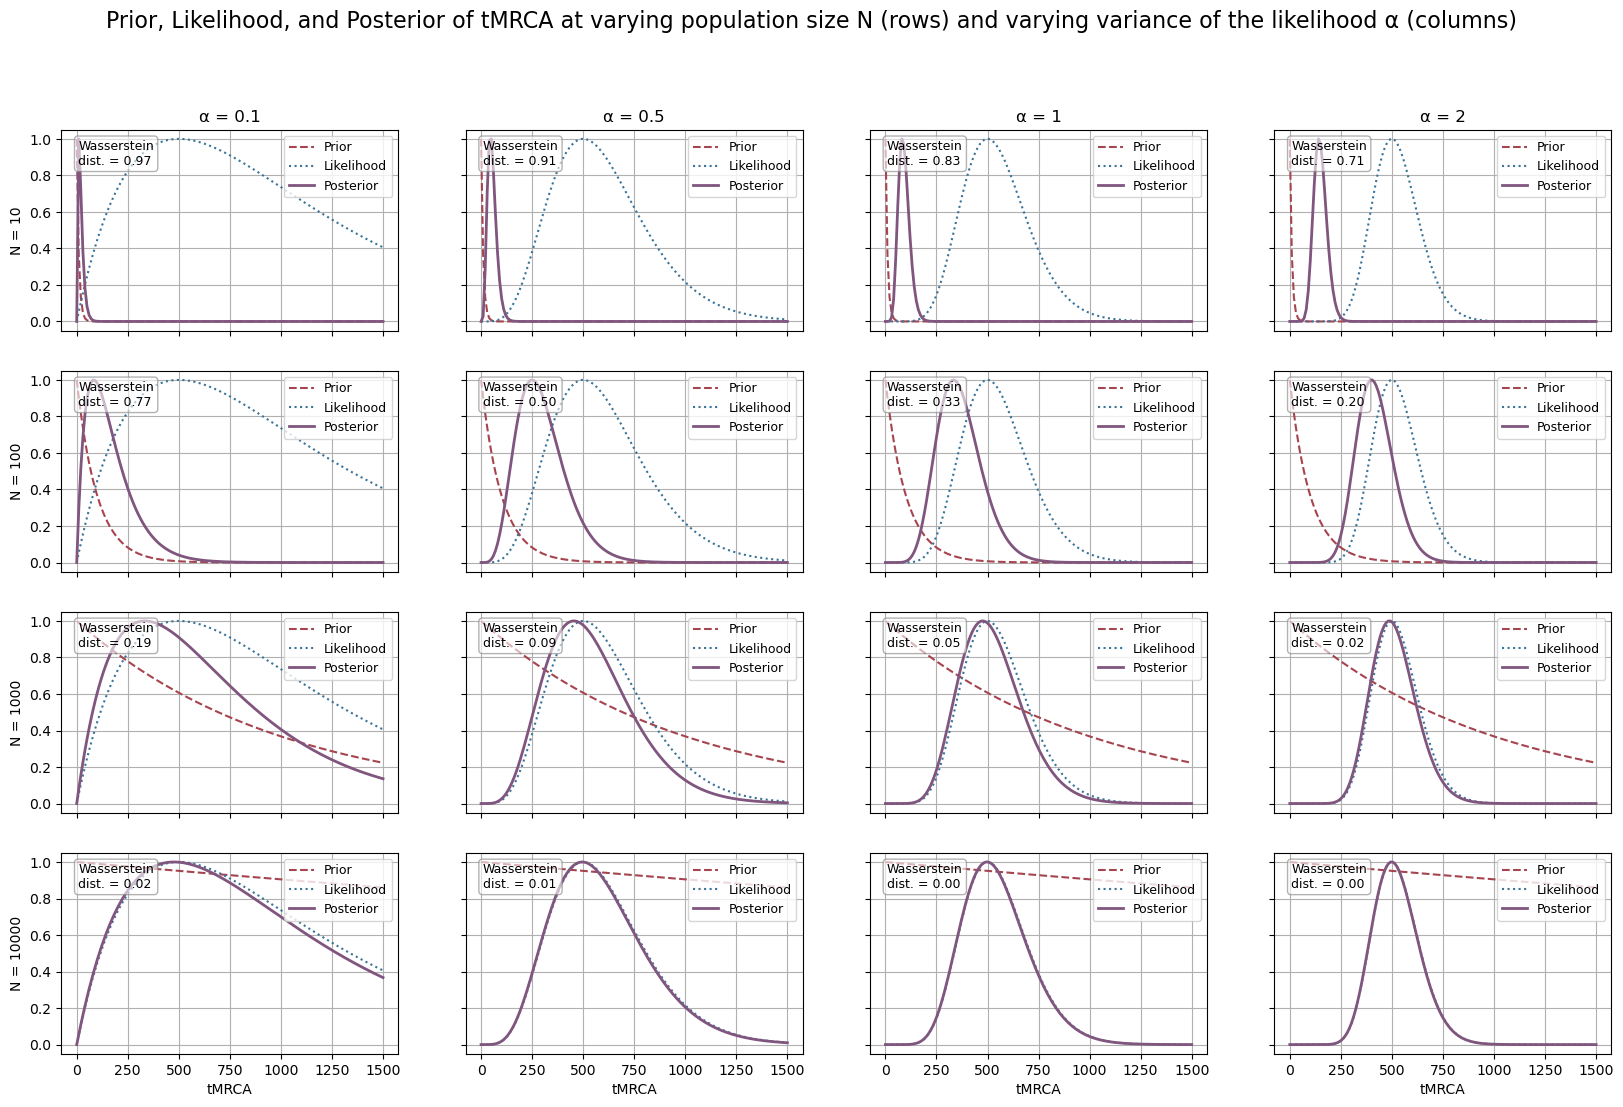

In [22]:
# Setup parameters
L = 100
N_values = [10, 100, 1000, 10000]  # Rows
alpha_values = [0.1, 0.5, 1, 2]  # Columns
base_mu = 0.0001
base_k = 10
t_max = 1500  # Maximum tMRCA to consider

def plot_tMRCA(N_values, alpha_values, base_mu, base_k, t_max, L):
    """
    Plot the prior, likelihood, and posterior of tMRCA for varying population sizes and likelihood variances.
    
    Parameters:
    N_values (list): List of effective population sizes.
    alpha_values (list): List of variance multipliers for the likelihood.
    base_mu (float): Base mutation rate.
    base_k (int): Base number of mutations.
    t_values (np.array): Array of tMRCA values.
    L (int): Length of the genome in base pairs.
    """
    t_values = np.linspace(0, t_max, t_max//10)

    colors = [
        "#a6444f",  # Prior
        "#397398",  # Likelihood
        "#80557e",  # Posterior
    ]

    fig, axs = plt.subplots(len(N_values), len(alpha_values), figsize=(20, 12), sharex=True, sharey=True)

    for row, N in enumerate(N_values):
        for col, alpha in enumerate(alpha_values):
            mu = base_mu * alpha
            k_mut = int(base_k * alpha) if int(base_k * alpha) > 0 else 1  # ensure at least 1

            likelihoods = np.array([likelihood_tMRCA_mutations(k_mut, mu, t, L) for t in t_values])
            priors = np.array([coalescent_prior(t, N) for t in t_values])
            posteriors = likelihoods * priors

            # Normalize
            likelihoods /= np.max(likelihoods) if np.max(likelihoods) > 0 else 1
            priors /= np.max(priors) if np.max(priors) > 0 else 1
            posteriors /= np.max(posteriors) if np.max(posteriors) > 0 else 1

            ax = axs[row, col]
            ax.plot(t_values, priors, linestyle="--", color=colors[0], label="Prior")
            ax.plot(t_values, likelihoods, linestyle=":", color=colors[1], label="Likelihood")
            ax.plot(t_values, posteriors, linewidth=2, color=colors[2], label="Posterior")
            ax.grid(True)

            # Renormalize to proper probability distributions for integration
            posterior_norm = posteriors / np.trapezoid(posteriors, t_values)
            likelihood_norm = likelihoods / np.trapezoid(likelihoods, t_values)

            # Compute Wasserstein distance and normalize
            w_dist = wasserstein_distance(t_values, t_values, posterior_norm, likelihood_norm)
            expected_likelihood = np.trapezoid(t_values * likelihood_norm, t_values)
            rel_w_dist = w_dist / expected_likelihood if expected_likelihood > 0 else np.nan

            if row == len(N_values) - 1:
                ax.set_xlabel("tMRCA")
            if col == 0:
                ax.set_ylabel(f"N = {N}")
            if row == 0:
                ax.set_title(f"α = {alpha}")

            ax.legend(loc="upper right", fontsize=9)

            # Annotate normalized Wasserstein distance
            ax.text(
                0.05, 0.95,
                f"Wasserstein\ndist. = {rel_w_dist:.2f}",
                transform=ax.transAxes,
                fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.6)
            )



    #axs[0, 0].legend(loc="upper right", fontsize=9)
    plt.suptitle("Prior, Likelihood, and Posterior of tMRCA at varying population size N (rows) and varying variance of the likelihood α (columns)", fontsize=16)
    #plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_tMRCA(N_values, alpha_values, base_mu, base_k, t_max, L)

The values of the relative Wasserstein distance (relative to the expected tMRCA) show by how many units of what we expected the prior shifted the estimated posterior. For the high likelihood variance, low N case, the distance is close to 1 which suggests a full scale shift. For the low likelihood variance, high N case, the relative Wasserstein distance is 0.

## Extend to time-varying population size

Later this can be extended to models of varying population size, e.g. an exponentially growing population size $N(t) = N_0 \cdot e^{\beta t}$. This gives for the prior:
$$
P(t_{MRCA}|N) = \frac{1}{N_0} e^{-\beta(t_{\text{present}} - t_{MRCA})} \cdot e^{-\frac{1}{N_0 \cdot \beta} e^{-\beta t_{\text{present}}} \left( e^{\beta t_{MRCA}} - 1 \right)}
$$

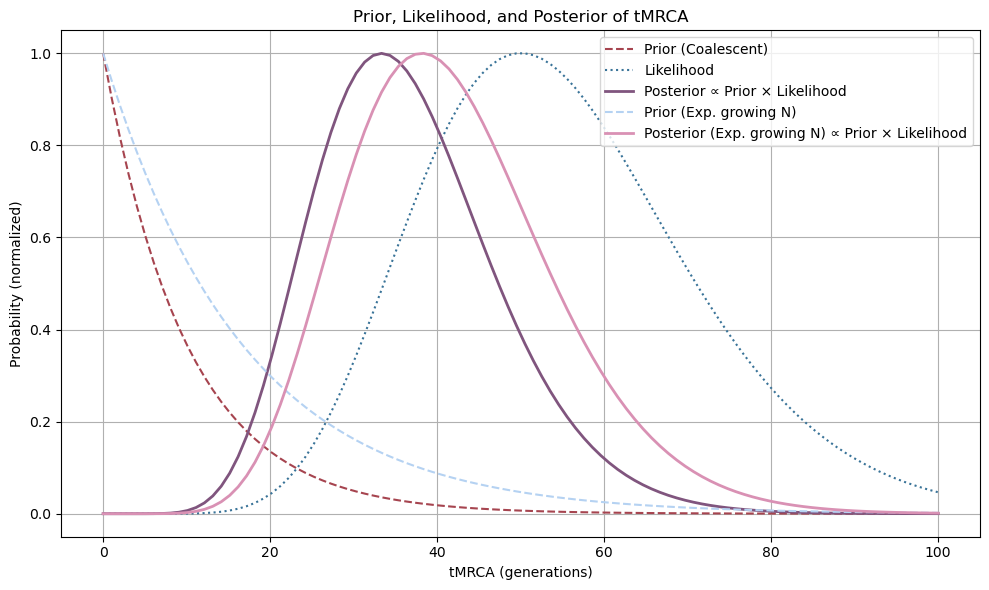

In [23]:
# Parameters
mu = 1e-3        # mutation rate per base per generation
L = 100          # genome length
k_mut = 10        # observed mutations
N = 10         # effective population size

t_present = 500
beta = 0.001
N_0 = 10

# Time grid
t_values = np.linspace(0, 100, 100)

# Compute values
likelihoods = np.array([likelihood_tMRCA_mutations(k_mut, mu, t, L) for t in t_values])
priors = np.array([coalescent_prior(t, N) for t in t_values])
priors_expN = np.array([coalescent_prior_expN(t, N_0, beta, t_present) for t in t_values])
posteriors = likelihoods * priors
posteriors_expN = likelihoods * priors_expN

# Normalize for better visualization
likelihoods /= np.max(likelihoods)
priors /= np.max(priors)
posteriors /= np.max(posteriors)
priors_expN /= np.max(priors_expN)
posteriors_expN /= np.max(posteriors_expN)

colors = [
        "#a6444f",  # reddish
        "#397398",  # dark blue
        "#80557e",  # purple
        "#b5d2f2",  # light blue
        "#d991b4",  # pink
        "#57a8b8",  # teal
        "#7394c2",  # mid blue
        "#7a7a7a"   # gray
    ]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_values, priors, label="Prior (Coalescent)", linestyle="--", color = colors[0])
plt.plot(t_values, likelihoods, label="Likelihood", linestyle=":", color = colors[1])
plt.plot(t_values, posteriors, label="Posterior ∝ Prior × Likelihood", linewidth=2, color = colors[2])
plt.plot(t_values, priors_expN, label="Prior (Exp. growing N)", linestyle="--", color = colors[3])
plt.plot(t_values, posteriors_expN, label="Posterior (Exp. growing N) ∝ Prior × Likelihood", linewidth=2, color = colors[4])
plt.xlabel("tMRCA (generations)")
plt.ylabel("Probability (normalized)")
plt.title("Prior, Likelihood, and Posterior of tMRCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()